
# Fake Γ diagnosis tests for kagome fRG

This notebook is a **standalone diagnosis sanity-check notebook**.

It does **not** depend on your full flow results.  
Instead, it builds a minimal synthetic patch set and injects several **fake full vertices** $\Gamma$ directly into `FRGFlowSolver`, then calls:

```python
solver.build_diagnosis_kernel_dict(Q)
```

The goal is to answer a very specific question:

> If we feed diagnosis a vertex that is **by construction**
> - pure **ph-spin** at $Q=0$,
> - pure **pp-singlet** at $Q=0$,
> - optionally pure **ph-charge** at finite $Q$,
>
> does the current diagnosis pipeline return the expected leading kernel?

---

## What this notebook tests

### Test A
A fake **FM-like** full vertex:
- ph-spin longitudinal structure
- $Q=0$

Expected:
- `ph_spin_longitudinal` should dominate at $Q=0$.

### Test B
A fake **pp-singlet** full vertex:
- pure pp singlet structure
- $Q=0$

Expected:
- `pp_singlet_sz0` should dominate at $Q=0$.

### Test C
A fake **finite-Q ph-charge** full vertex:
- ph longitudinal charge structure
- one nonzero transfer momentum from the internal transfer grid

Expected:
- `ph_charge_longitudinal` should dominate at that finite $Q$.

---

## Reading the results

If Test A fails badly (for example the fake FM vertex is classified as dominant `pp_singlet_sz0`), then the diagnosis kernel construction is highly suspect.

If Test A and Test B both pass, then:
- the diagnosis routing / spin-combination layer is at least **basically self-consistent**,
- and your real-project pathology is more likely to come from the **actual flowing vertex** rather than this fake-Γ readout layer alone.


In [1]:

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make sure the uploaded project files are importable
PROJECT_DIR = Path("/mnt/data")
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from patching import PatchPoint, PatchSet
from frg_flow import FRGFlowSolver


## 1. Build a minimal symmetric patch set

In [2]:

def make_circle_patchset(Npatch=8, radius=1.0):
    """
    Minimal synthetic patch set on a circle.
    This is NOT intended to reproduce kagome physics.
    It only provides a clean geometry for diagnosis sanity tests.
    """
    if Npatch % 2 != 0:
        raise ValueError("Use an even Npatch so that Q=0 pp partner mapping is well-defined.")

    b1 = np.array([2*np.pi, 0.0], dtype=float)
    b2 = np.array([0.0, 2*np.pi], dtype=float)
    B = np.column_stack([b1, b2])

    patches = []
    for i in range(Npatch):
        theta = 2*np.pi*i/Npatch
        k = np.array([radius*np.cos(theta), radius*np.sin(theta)], dtype=float)
        kred = np.linalg.solve(B, k)

        # trivial 3-orbital eigenvector just to satisfy interfaces
        eigvec = np.array([1.0 + 0.0j, 0.0 + 0.0j, 0.0 + 0.0j], dtype=complex)

        patches.append(
            PatchPoint(
                patch_id=i,
                k_cart=k,
                k_red=kred,
                energy=0.0,
                vF=np.array([-np.sin(theta), np.cos(theta)], dtype=float),
                vF_norm=1.0,
                eigvec=eigvec,
                orbital_weight=np.array([1.0, 0.0, 0.0], dtype=float),
            )
        )

    ps = PatchSet(
        mu=0.0,
        mu_used_for_contour=0.0,
        band_index=0,
        filling=0.0,
        patches=patches,
        fs_contour_k=np.array([p.k_cart for p in patches], dtype=float),
        bz_vertices=np.zeros((4, 2), dtype=float),
        b1=b1,
        b2=b2,
    )
    return ps

Npatch = 8
patchset_up = make_circle_patchset(Npatch=Npatch, radius=1.0)
patchset_dn = make_circle_patchset(Npatch=Npatch, radius=1.0)
patchsets = {"up": patchset_up, "dn": patchset_dn}

print("Npatch =", patchset_up.Npatch)
print("first few patch momenta:")
for p in patchset_up.patches[:4]:
    print(p.patch_id, np.round(p.k_cart, 4))


Npatch = 8
first few patch momenta:
0 [1. 0.]
1 [0.7071 0.7071]
2 [0. 1.]
3 [-0.7071  0.7071]


## 2. Build a baseline solver (used only for transfer-grid / partner-map helpers)

In [3]:

def zero_gamma(p1, s1, p2, s2, p3, s3, p4, s4):
    return 0.0 + 0.0j

solver_ref = FRGFlowSolver(
    patchsets=patchsets,
    bare_gamma=zero_gamma,
    T_start=1.0,
    T_stop=0.5,
    n_steps=2,
    diagnosis_Qs=[np.zeros(2, dtype=float)],
)

Q0 = np.zeros(2, dtype=float)
print("diagnosis_Qs:", [np.round(q, 6) for q in solver_ref.diagnosis_Qs])
print("number of pp transfer momenta:", len(solver_ref.pp_grid.q_list))
print("number of ph transfer momenta:", len(solver_ref.phd_grid.q_list))


diagnosis_Qs: [array([0., 0.])]
number of pp transfer momenta: 33
number of ph transfer momenta: 33


## 3. Helper functions: fake full vertices Γ

In [4]:

def make_fake_fm_gamma():
    """
    Fake full vertex designed so that ph_spin_longitudinal at Q=0 is dominant.

    Structure:
        Gamma ~ delta_{p1,p3} delta_{p2,p4} * spin_factor
    with spin_factor chosen to enhance longitudinal spin response.
    """
    coeff = {
        ("up", "up", "up", "up"): +1.0,
        ("dn", "dn", "dn", "dn"): +1.0,
        ("up", "dn", "dn", "up"): -1.0,
        ("dn", "up", "up", "dn"): -1.0,
    }

    def gamma(p1, s1, p2, s2, p3, s3, p4, s4):
        if (p1 == p3) and (p2 == p4):
            return coeff.get((s1, s2, s3, s4), 0.0) + 0.0j
        return 0.0 + 0.0j

    return gamma


def make_fake_pp_singlet_gamma(solver, Q=np.zeros(2, dtype=float)):
    """
    Fake full vertex designed so that pp_singlet_sz0 is dominant
    for the chosen pp transfer momentum Q (default Q=0).
    """
    iq = solver.pp_grid.nearest_index(Q)

    partner = {}
    for sa, sb in [("up", "dn"), ("dn", "up"), ("up", "up"), ("dn", "dn")]:
        arr, _ = solver._partner_map_pp_from_iq(iq, first_spin=sa, second_spin=sb, Q=Q)
        partner[(sa, sb)] = np.asarray(arr, dtype=int)

    coeff = {
        ("up", "dn", "up", "dn"): +1.0,
        ("up", "dn", "dn", "up"): -1.0,
        ("dn", "up", "up", "dn"): -1.0,
        ("dn", "up", "dn", "up"): +1.0,
    }

    def gamma(p1, s1, p2, s2, p3, s3, p4, s4):
        if partner[(s1, s2)][p1] != p2:
            return 0.0 + 0.0j
        if partner[(s3, s4)][p3] != p4:
            return 0.0 + 0.0j
        return coeff.get((s1, s2, s3, s4), 0.0) + 0.0j

    return gamma


def make_fake_ph_longitudinal_gamma(solver, Q, kind="charge"):
    """
    Fake full vertex designed so that a longitudinal ph channel dominates
    for a chosen transfer momentum Q.

    kind = "charge" or "spin"
    """
    iq = solver.phd_grid.nearest_index(Q)

    maps = {}
    for sa, sb in [("up", "up"), ("up", "dn"), ("dn", "up"), ("dn", "dn")]:
        arr, _ = solver._partner_map_phd_from_iq(iq, first_spin=sa, second_spin=sb, Q=Q)
        maps[(sa, sb)] = np.asarray(arr, dtype=int)

    if kind == "spin":
        coeff = {
            ("up", "up", "up", "up"): +1.0,
            ("up", "dn", "dn", "up"): -1.0,
            ("dn", "up", "up", "dn"): -1.0,
            ("dn", "dn", "dn", "dn"): +1.0,
        }
    elif kind == "charge":
        coeff = {
            ("up", "up", "up", "up"): +1.0,
            ("up", "dn", "dn", "up"): +1.0,
            ("dn", "up", "up", "dn"): +1.0,
            ("dn", "dn", "dn", "dn"): +1.0,
        }
    else:
        raise ValueError("kind must be 'charge' or 'spin'")

    def gamma(p1, s1, p2, s2, p3, s3, p4, s4):
        # Consistent with _vertex_phd_kernel routing:
        # p3 should be k(p1)+Q in the (s1,s3) channel
        # p2 should be k(p4)+Q in the (s4,s2) channel
        if maps[(s1, s3)][p1] != p3:
            return 0.0 + 0.0j
        if maps[(s4, s2)][p4] != p2:
            return 0.0 + 0.0j
        return coeff.get((s1, s2, s3, s4), 0.0) + 0.0j

    return gamma


## 4. Analysis utilities

In [5]:

def build_solver_for_gamma(gamma_fn, diagnosis_Qs):
    return FRGFlowSolver(
        patchsets=patchsets,
        bare_gamma=gamma_fn,
        T_start=1.0,
        T_stop=0.5,
        n_steps=2,
        diagnosis_Qs=diagnosis_Qs,
    )

def kernel_spectrum_table(solver, Q, sort_by="abs"):
    kernels = solver.build_diagnosis_kernel_dict(Q)
    rows = []
    for name, ker in kernels.items():
        vals = np.linalg.eigvals(ker.matrix)
        if len(vals) == 0:
            lead_abs = 0.0
            lead_real = 0.0
        else:
            lead_abs = float(np.max(np.abs(vals)))
            lead_real = float(np.max(np.real(vals)))
        rows.append({
            "kernel": name,
            "lead_abs_eval": lead_abs,
            "lead_real_eval": lead_real,
            "max_entry_abs": float(np.max(np.abs(ker.matrix))) if ker.matrix.size else 0.0,
            "hermitian_residual": float(np.max(np.abs(ker.matrix - ker.matrix.conjugate().T))),
        })
    df = pd.DataFrame(rows).sort_values(["lead_abs_eval", "lead_real_eval"], ascending=False).reset_index(drop=True)
    return df, kernels

def show_top_kernels(df, title="", n=12):
    display(df.head(n))
    top = df.head(min(n, len(df))).copy()
    plt.figure(figsize=(10, 4))
    plt.bar(top["kernel"], top["lead_abs_eval"])
    plt.xticks(rotation=70, ha="right")
    plt.ylabel("leading |eigenvalue|")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def summarize_expected_winner(df):
    row = df.iloc[0]
    print(f"Top kernel: {row['kernel']}  |  leading |eigenvalue| = {row['lead_abs_eval']:.6g}")


## 5. Test A: fake FM vertex at Q = 0

,kernel,lead_abs_eval,lead_real_eval,max_entry_abs,hermitian_residual
0,ph_spin_longitudinal,16.0,1.600000e+01,2.0,0.0
1,phd_uu,8.0,8.000000e+00,1.0,0.0
2,phd_dd,8.0,8.000000e+00,1.0,0.0
3,phd_uu_to_uu,8.0,8.000000e+00,1.0,0.0
4,phd_dd_to_dd,8.0,8.000000e+00,1.0,0.0
5,phd_uu_to_dd,8.0,3.487136e-126,1.0,0.0
6,phd_dd_to_uu,8.0,3.487136e-126,1.0,0.0
7,pp_singlet_sz0,1.0,1.000000e+00,1.0,0.0
8,pp_triplet_uu,1.0,1.000000e+00,1.0,0.0
9,phc_uu,1.0,1.000000e+00,1.0,0.0


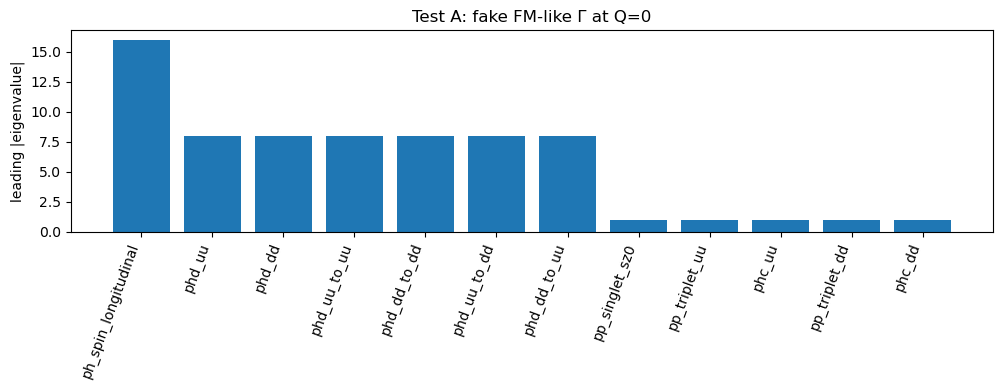

Top kernel: ph_spin_longitudinal  |  leading |eigenvalue| = 16
Expected winner: ph_spin_longitudinal


In [6]:

gamma_fm = make_fake_fm_gamma()
solver_fm = build_solver_for_gamma(gamma_fm, diagnosis_Qs=[Q0])

df_fm, kernels_fm = kernel_spectrum_table(solver_fm, Q0)
show_top_kernels(df_fm, title="Test A: fake FM-like Γ at Q=0", n=12)
summarize_expected_winner(df_fm)

print("Expected winner: ph_spin_longitudinal")


## 6. Test B: fake pp-singlet vertex at Q = 0

,kernel,lead_abs_eval,lead_real_eval,max_entry_abs,hermitian_residual
0,pp_singlet_sz0,16.0,1.600000e+01,2.0,0.0
1,pp_ud_to_ud,8.0,8.000000e+00,1.0,0.0
2,pp_du_to_du,8.0,8.000000e+00,1.0,0.0
3,pp_ud_to_du,8.0,3.487136e-126,1.0,0.0
4,pp_du_to_ud,8.0,3.487136e-126,1.0,0.0
5,phd_uu_to_dd,1.0,1.000000e+00,1.0,0.0
6,phd_dd_to_uu,1.0,1.000000e+00,1.0,0.0
7,ph_charge_longitudinal,1.0,1.000000e+00,1.0,0.0
8,ph_spin_longitudinal,1.0,1.000000e+00,1.0,0.0
9,pp_triplet_sz0,0.0,0.000000e+00,0.0,0.0


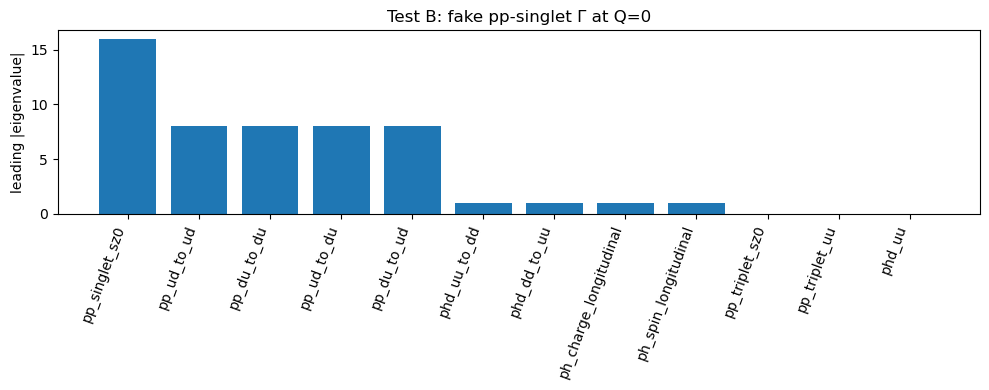

Top kernel: pp_singlet_sz0  |  leading |eigenvalue| = 16
Expected winner: pp_singlet_sz0


In [7]:

gamma_pp = make_fake_pp_singlet_gamma(solver_ref, Q=Q0)
solver_pp = build_solver_for_gamma(gamma_pp, diagnosis_Qs=[Q0])

df_pp, kernels_pp = kernel_spectrum_table(solver_pp, Q0)
show_top_kernels(df_pp, title="Test B: fake pp-singlet Γ at Q=0", n=12)
summarize_expected_winner(df_pp)

print("Expected winner: pp_singlet_sz0")


## 7. Test C: fake finite-Q ph-charge vertex

,kernel,lead_abs_eval,lead_real_eval,max_entry_abs,hermitian_residual
0,ph_charge_longitudinal,4.0,4.0,2.0,0.0
1,phd_uu,2.0,2.0,1.0,0.0
2,phd_dd,2.0,2.0,1.0,0.0
3,phd_uu_to_uu,2.0,2.0,1.0,0.0
4,phd_uu_to_dd,2.0,2.0,1.0,0.0
5,phd_dd_to_uu,2.0,2.0,1.0,0.0
6,phd_dd_to_dd,2.0,2.0,1.0,0.0
7,pp_ud_to_ud,0.0,0.0,0.0,0.0
8,pp_ud_to_du,0.0,0.0,0.0,0.0
9,pp_du_to_ud,0.0,0.0,0.0,0.0


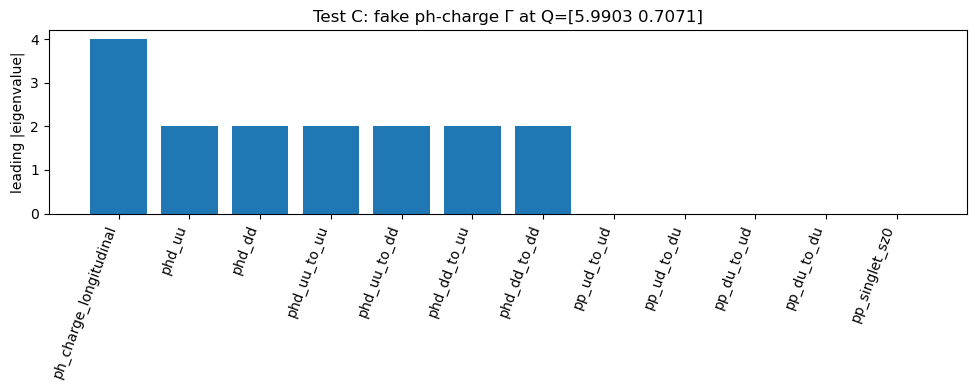

Top kernel: ph_charge_longitudinal  |  leading |eigenvalue| = 4
Expected winner: ph_charge_longitudinal
Chosen finite Q = [5.990292 0.707107]


In [8]:

# Pick one nonzero Q already present in the ph transfer grid
nonzero_ph_Qs = [q for q in solver_ref.phd_grid.q_list if np.linalg.norm(q) > 1e-10]
Qph = np.asarray(nonzero_ph_Qs[0], dtype=float)

gamma_ph_charge = make_fake_ph_longitudinal_gamma(solver_ref, Q=Qph, kind="charge")
solver_ph_charge = build_solver_for_gamma(gamma_ph_charge, diagnosis_Qs=[Qph])

df_ph_charge, kernels_ph_charge = kernel_spectrum_table(solver_ph_charge, Qph)
show_top_kernels(df_ph_charge, title=f"Test C: fake ph-charge Γ at Q={np.round(Qph, 4)}", n=12)
summarize_expected_winner(df_ph_charge)

print("Expected winner: ph_charge_longitudinal")
print("Chosen finite Q =", np.round(Qph, 6))


## 8. Compact summary

In [9]:

summary = pd.DataFrame([
    {"test": "A: fake FM @ Q=0", "expected": "ph_spin_longitudinal", "observed_top": df_fm.iloc[0]["kernel"]},
    {"test": "B: fake pp-singlet @ Q=0", "expected": "pp_singlet_sz0", "observed_top": df_pp.iloc[0]["kernel"]},
    {"test": "C: fake ph-charge @ finite Q", "expected": "ph_charge_longitudinal", "observed_top": df_ph_charge.iloc[0]["kernel"]},
])
display(summary)

all_pass = (
    (summary.iloc[0]["observed_top"] == "ph_spin_longitudinal") and
    (summary.iloc[1]["observed_top"] == "pp_singlet_sz0") and
    (summary.iloc[2]["observed_top"] == "ph_charge_longitudinal")
)

print("All three headline tests pass:", all_pass)


,test,expected,observed_top
0,A: fake FM @ Q=0,ph_spin_longitudinal,ph_spin_longitudinal
1,B: fake pp-singlet @ Q=0,pp_singlet_sz0,pp_singlet_sz0
2,C: fake ph-charge @ finite Q,ph_charge_longitudinal,ph_charge_longitudinal


All three headline tests pass: True



## 9. How to interpret the outcome

### If Test A / B / C all pass
Then the **basic routing + spin-combination layer in diagnosis is at least self-consistent** on controlled synthetic inputs.

That does **not** prove your full kagome diagnosis is correct, but it strongly suggests that the problem in your real runs is **not simply** “diagnosis always maps everything to pp”.

---

### If Test A fails
For example, if the fake FM vertex gets read out mainly as `pp_singlet_sz0`, then the diagnosis kernel construction is highly suspect.

---

### If Test C fails while A/B pass
Then the likely weak point is the **finite-Q particle-hole routing / partner-map / leg-ordering layer**, not the whole diagnosis pipeline.

---

### Next natural follow-up
After this notebook, the next decisive check is:

1. Compare `||Φ_pp||`, `||Φ_phd||`, `||Φ_phc||` during the real flow.
2. Build a **fake Γ from your actual stored channel corrections**:
   - `Γ_fake = Γ_bare + Φ_phd + Φ_phc`
   - `Γ_fake = Γ_bare + Φ_pp`
3. Feed those into the same diagnosis code.
